In [3]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
from scipy.stats import chisquare
from scipy.stats import chi2
from scipy.stats import percentileofscore
#from scipy.stats import chi2_contingency
#from statsmodels.stats.weightstats import ttest_ind as sm_ttest_ind
from statsmodels.stats.power import tt_ind_solve_power
from statsmodels.stats.proportion import proportion_confint
from scipy.stats  import gaussian_kde

from tqdm import tqdm
from scipy.stats import bootstrap
from scipy.stats import shapiro

from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

# Bootstrap

## Структура урока
- посмотрим, что такое эмпирическая функция распределения
- проведем одну итерацию бутстрапа
- построим доверительные интервалы в бутстрапе разными способами. Посмотрим их плюсы и минусы
- посмотрим покрываемость ДИ в бутстрапе
- проверка гипотез с помощью бутстрапа. ДИ и p-value
- проверка гипотез по квантилям. Децильный анализ в ARPU
- проверка бутсрапа как оценщика

Как мы видим, критерии не всегда работают так как хотелось бы, либо не всегда легко интерпретируемы. Рассмотрим такой способ оценки как bootstrap.

Посмотрим сходимость Эмпирической функции распределения.

Попробуем сделать  оценку для нормального распределения.

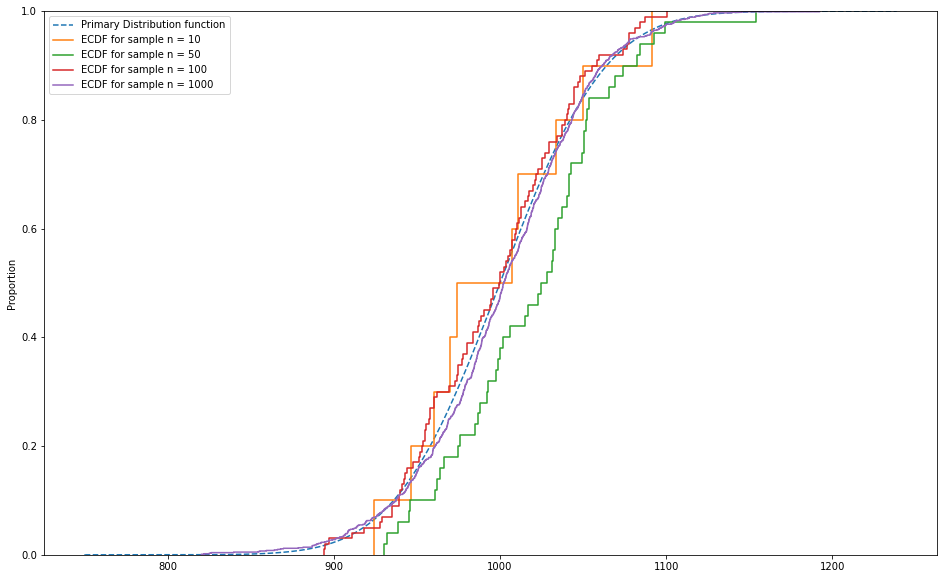

In [4]:
primary_data = np.random.normal(1000, 50, 1000000) # предположим что это наше исходное распределение, нормальное

# сгенерируем несколько выборок разного размера
sample_data_n10 = np.random.choice(primary_data, size=10, replace=True)
sample_data_n50 = np.random.choice(primary_data, size=50, replace=True)
sample_data_n100 = np.random.choice(primary_data, size=100, replace=True)
sample_data_n1000 = np.random.choice(primary_data, size=1000, replace=True)
sample_data_n10000 = np.random.choice(primary_data, size=10000, replace=True)

# посмотрим как выглядят функции распределения для каждой из них
plt.figure(figsize=(16,10))
sns.ecdfplot(primary_data, label = 'Primary Distribution function', linestyle ='--')
sns.ecdfplot(sample_data_n10, label = 'ECDF for sample n = 10')
sns.ecdfplot(sample_data_n50, label = 'ECDF for sample n = 50')
sns.ecdfplot(sample_data_n100, label = 'ECDF for sample n = 100')
sns.ecdfplot(sample_data_n1000, label = 'ECDF for sample n = 1000')
plt.legend()

Как мы видим, эмпирическая функция распределения по мере роста размера выборки стремится к исходному распределению.

Для работы с бутстрапом нам часто нужно будет получать много выборок с повторениями.

Функция, которая быстро возвращает resample выборку с возвращением.

In [5]:
# возвращаем одну подвыборку размером 100 с возвращением
np.random.choice(primary_data, size=100, replace=True)

array([ 969.009789  ,  955.07412091, 1036.18917725,  968.57575358,
        893.5274489 ,  992.06986813,  933.9295393 , 1020.188544  ,
       1044.32220696,  961.84444734,  954.58797324,  955.16662146,
        923.21069574,  943.02888208, 1054.58618374, 1097.32958083,
       1020.74364001, 1041.76520393, 1068.81919404,  984.97945503,
       1059.91433996,  987.25430059, 1133.43518976,  841.72958266,
        971.50155478,  956.32664099, 1001.82134842, 1001.48839881,
       1103.58885865, 1068.56322441,  998.17975032, 1016.08359943,
       1119.77492009,  988.72399581,  988.24809958, 1029.65197256,
        989.10212111,  932.81354039,  970.69815424, 1045.33851909,
        928.26564217,  960.5571319 , 1001.15665754, 1062.82912189,
        971.47276356, 1150.86236873,  977.89104626,  987.03237491,
        969.67841839, 1035.03336557,  972.26366528, 1018.05703056,
        898.69887449,  899.80029219, 1078.28968238,  990.42309654,
       1037.64057801, 1052.82464814, 1017.37874658,  942.32289

In [8]:
# возвращаем 10 подвыборок размером 100 с возвращением
np.random.choice(primary_data, (10, 100), True)

array([[1006.90532103, 1014.56714005,  965.94008333, 1108.44184843,
        1025.5755558 ,  941.61940715,  990.18889823, 1027.51018588,
         988.85453796,  943.29990435,  992.16189465,  986.22594585,
        1028.52699081, 1082.71594814,  951.50812011,  980.54588905,
        1034.50565509, 1014.73330683,  998.4647988 ,  957.95317584,
        1047.51382088, 1004.88854849,  984.05372548,  952.85837703,
        1058.62245938,  864.58303428, 1069.35777824, 1055.38279834,
         998.13544539,  954.8587715 , 1053.34321648, 1017.91942284,
         924.93170479, 1048.90918376, 1039.35941255, 1084.85599811,
        1008.6050105 , 1053.2915729 ,  969.11951578, 1010.04718634,
        1022.02374131, 1062.43781837,  997.8076057 , 1045.17844605,
        1000.42395761, 1057.97705311, 1028.79414866, 1036.14883161,
        1015.24067255,  928.39165749,  890.71648493,  984.17749427,
         972.71234213,  954.02694304, 1075.30372197,  956.77515516,
         983.56994254,  985.44440327, 1054.39837

## Прогоним Бутстрап 1 раз

- Посмотрим работу бутстрапа на практике. Оценим среднюю и стандартное отклонение через ресэмплинг
- Сравним с выборочной оценкой этих статистик.
- Попробуем оценить доверительные интервалы в выборочном методе и бутстрапе

Theoretical mean = 1000
Theoretical std = 50
--------------
Resample mean = 1007.3676158253463
Resample std = 48.62629708021637
--------------
Bootstraped mean = 1006.79
Bootstraped std = 48.63


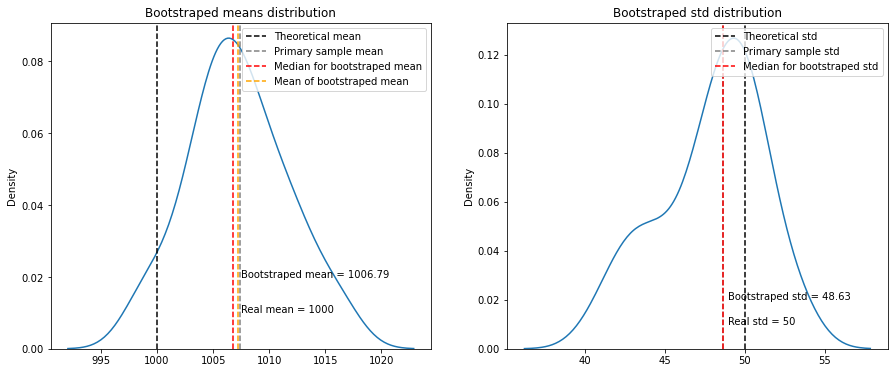

In [29]:
#np.random.seed(2)
mean = 1000
std = 50
sample_size = 100

# получаем исходные данные
first_sample_data = np.random.normal(mean, std, sample_size)
print('Theoretical mean =', mean)
print('Theoretical std =',std)
print('--------------')
print('Resample mean =', first_sample_data.mean())
print('Resample std =',first_sample_data.std())

n_resample = 50 # количество ресемпл выборок
resample_means_list = [] # лист для записи средних из каждой выборки
resample_std_list = [] # лист для записи std из каждой выборки

# прогоняем цикл для извлечения n_resample раз
for _ in range(n_resample):
    resample_data = np.random.choice(first_sample_data, size=len(first_sample_data), replace=True)
    resample_mean = resample_data.mean()
    resample_std = resample_data.std()
    resample_means_list.append(resample_mean)
    resample_std_list.append(resample_std)

means_median = round(np.quantile(resample_means_list, 0.5), 2)
std_median = round(np.quantile(resample_std_list, 0.5), 2)

print('--------------')
print('Bootstraped mean =', means_median)
print('Bootstraped std =', std_median)


# отрисуем графики полученных оценок средней и стандартного оклонения и сравним с генеральными параметрами и первичной выборкой
fig, axes = plt.subplots(1, 2, figsize=(15,6))

sns.kdeplot(ax=axes[0], data = resample_means_list)
axes[0].set_title('Bootstraped means distribution')
axes[0].axvline(x=mean, linestyle = '--', color = 'black', label = 'Theoretical mean')
axes[0].axvline(x=first_sample_data.mean(), linestyle = '--', color = 'gray', label = 'Primary sample mean')
axes[0].axvline(x=np.quantile(resample_means_list, 0.5), linestyle = '--', color = 'red', label = 'Median for bootstraped mean')
axes[0].axvline(x=np.mean(resample_means_list), linestyle = '--', color = 'orange', label = 'Mean of bootstraped mean')
axes[0].text(np.quantile(resample_means_list, 0.55), 0.02, 'Bootstraped mean = {}'.format(means_median))
axes[0].text(np.quantile(resample_means_list, 0.55), 0.01, 'Real mean = {}'.format(mean))
axes[0].legend(loc='upper right')

sns.kdeplot(ax=axes[1], data = resample_std_list)
axes[1].set_title('Bootstraped std distribution')
axes[1].axvline(x=std, linestyle = '--', color = 'black', label = 'Theoretical std')
axes[1].axvline(x=first_sample_data.std(), linestyle = '--', color = 'gray', label = 'Primary sample std')
axes[1].axvline(x=np.quantile(resample_std_list, 0.5), linestyle = '--', color = 'red', label = 'Median for bootstraped std')
axes[1].text(np.quantile(resample_std_list, 0.55), 0.02, 'Bootstraped std = {}'.format(std_median))
axes[1].text(np.quantile(resample_std_list, 0.55), 0.01, 'Real std = {}'.format(std))
axes[1].legend(loc='upper right')

Как мы видим, бутстрапирование создает симметричное и колоколообразное распределение оценок оцениваемой статистики.

При этом мы видим, что центральная тенденция распределения стремится с выборочной средней исходной первой выборки, которую мы используем для ресемплинга. Это видно и для оценки стандартного отклонения. Т.е. бутстрап старается воспроизвести не исходный параметр, а полученный по первичной выборке.

# Расмотрим несколько способов построения ДИ в бутстрапе

Theoretical mean = 1000
Theoretical std = 50
--------------
Resample mean = 1001.9406238079802
Resample std = 49.05020669661059
--------------
Bootstraped mean = 1001.92
Bootstraped std = 49.0
--------------
95% bootstrapped percentile CI for mean: (998.8457392170571, 1004.985525009894)
95% bootstrapped percentile CI for std: (46.79328260793739, 51.289628600594014)
95% sample CI for mean: (998.9004604998588, 1004.9807871161015)
95% sample CI for std: (46.96818819609709, 51.273079504192495)


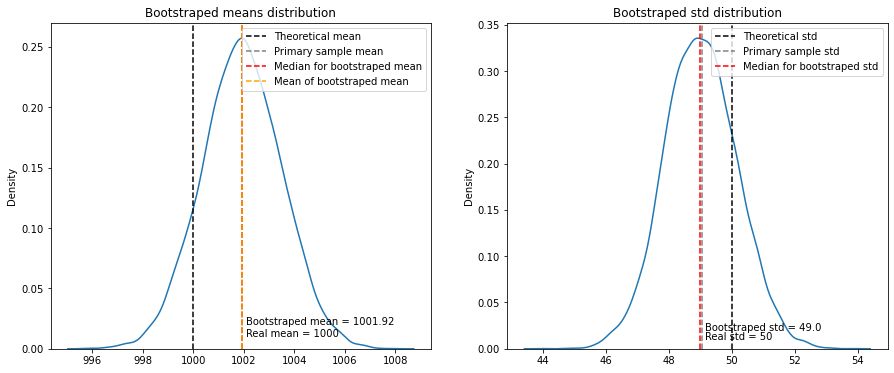

In [35]:
# сгенерируем первичную выборку
np.random.seed(12)
mean = 1000
std = 50
sample_size = 1000
np.random.seed(1)
first_sample_data = np.random.normal(mean, std, sample_size)
print('Theoretical mean =', mean)
print('Theoretical std =',std)
print('--------------')
print('Resample mean =', first_sample_data.mean())
print('Resample std =',first_sample_data.std())

n_resample = 10000 # кол-во извлечений resample выборок
resample_means_list = []
resample_std_list = []

for _ in range(n_resample):
    resample_data = np.random.choice(first_sample_data, size=len(first_sample_data), replace=True)
    resample_mean = resample_data.mean()
    resample_std = resample_data.std()
    resample_means_list.append(resample_mean)
    resample_std_list.append(resample_std)

means_median = round(np.quantile(resample_means_list, 0.5), 2)
std_median = round(np.quantile(resample_std_list, 0.5), 2)
print('--------------')
print('Bootstraped mean =', means_median)
print('Bootstraped std =', std_median)


# считаем доверительные интервалы для бутстрапа
boot_mean_perc_CI_95 = (np.quantile(resample_means_list, 0.025), np.quantile(resample_means_list, 0.975)) # извлечем 
#boot_norm_CI_perc_95 = (np.mean(resample_means_list) - np.std(resample_means_list)*1.96, np.mean(resample_means_list) + np.std(resample_means_list)*1.96)
boot_std_CI_95 = (np.quantile(resample_std_list, 0.025), np.quantile(resample_std_list, 0.975))

print('--------------')
print('95% bootstrapped percentile CI for mean:', boot_mean_perc_CI_95)
#print('95% bootstrapped norm CI for mean:', boot_norm_CI_perc_95)
print('95% bootstrapped percentile CI for std:', boot_std_CI_95)

# считаем доверительные интервалы для выборочной средней и стандартного отклонения
se = np.std(first_sample_data)/np.sqrt(sample_size)
sample_mean_CI_95 = (np.mean(first_sample_data) - 1.96*se, np.mean(first_sample_data) + 1.96*se)
sample_std_CI_95 = (np.sqrt((sample_size-1)/chi2(df = sample_size).ppf(0.975)) * np.std(first_sample_data),
                    np.sqrt((sample_size-1)/chi2(df = sample_size).ppf(0.025)) * np.std(first_sample_data))

print('95% sample CI for mean:', sample_mean_CI_95)
print('95% sample CI for std:', sample_std_CI_95)



fig, axes = plt.subplots(1, 2, figsize=(15,6))

sns.kdeplot(ax=axes[0], data = resample_means_list)
axes[0].set_title('Bootstraped means distribution')
axes[0].axvline(x=mean, linestyle = '--', color = 'black', label = 'Theoretical mean')
axes[0].axvline(x=first_sample_data.mean(), linestyle = '--', color = 'gray', label = 'Primary sample mean')
axes[0].axvline(x=np.quantile(resample_means_list, 0.5), linestyle = '--', color = 'red', label = 'Median for bootstraped mean')
axes[0].axvline(x=np.mean(resample_means_list), linestyle = '--', color = 'orange', label = 'Mean of bootstraped mean')
axes[0].text(np.quantile(resample_means_list, 0.55), 0.02, 'Bootstraped mean = {}'.format(means_median))
axes[0].text(np.quantile(resample_means_list, 0.55), 0.01, 'Real mean = {}'.format(mean))
axes[0].legend(loc='upper right')

sns.kdeplot(ax=axes[1], data = resample_std_list)
axes[1].set_title('Bootstraped std distribution')
axes[1].axvline(x=std, linestyle = '--', color = 'black', label = 'Theoretical std')
axes[1].axvline(x=first_sample_data.std(), linestyle = '--', color = 'gray', label = 'Primary sample std')
axes[1].axvline(x=np.quantile(resample_std_list, 0.5), linestyle = '--', color = 'red', label = 'Median for bootstraped std')
axes[1].text(np.quantile(resample_std_list, 0.55), 0.02, 'Bootstraped std = {}'.format(std_median))
axes[1].text(np.quantile(resample_std_list, 0.55), 0.01, 'Real std = {}'.format(std))
axes[1].legend(loc='upper right')

Выше мы попробовали построить перцентильный ДИ для оценки бутстрапом. Давайте рассмотрим еще несколько способов.

### Basic bootstrap confident interval

In [36]:
# basic bootstrap CI

left, right = 2 * np.mean(first_sample_data) - np.quantile(resample_means_list, [1 - 0.05 / 2,  0.05 / 2])
left, right

(998.8957226060663, 1005.0355083989032)

In [37]:
# basic bootstrap CI с помощью специальной библиотеки
data = (first_sample_data,)
res = bootstrap(data, n_resamples = 10000, statistic = np.mean, confidence_level = 0.95, method = 'basic', random_state = 1)
res.confidence_interval

ConfidenceInterval(low=998.8876022401358, high=1005.0095600865401)

### Percentile bootstrap CI

In [38]:
res = bootstrap(data, n_resamples = 10000, statistic = np.mean, confidence_level = 0.95, method = 'percentile', random_state = 1)
res.confidence_interval

ConfidenceInterval(low=998.8716875294202, high=1004.9936453758245)

In [39]:
left, right = np.quantile(resample_means_list, [0.05 / 2, 1 - 0.05 / 2])
left, right

(998.8457392170571, 1004.985525009894)

### Bootstrap-t CI

К сожалению, bootstrap-t не встроен в библиотеки. Напишем свои функции, полезные для работы с бутстрапом.

In [13]:
# функция, возвращающая resample выборок resample_num раз
def get_resampled_data(sample, sample_size, resample_num):
    resampled_data = np.random.choice(sample, size = (resample_num, sample_size), replace=True)
    return(resampled_data)

In [14]:
# функция, которая из полученных выборок достает заданную статистику
def get_resampled_stats(resampled_data, stat):
    resampled_stats = stat(resampled_data, axis = 1)
    return(resampled_stats)

In [15]:
# функция, которая достает квантили из resample выборок
def get_resampled_quantile(resampled_data, q=0.5):
    resampled_stats = np.quantile(resampled_data, q=q, axis = 1)
    return(resampled_stats)

In [42]:
# функция, которая достает t-преобразованные статистики из resample выборок 
def get_studentiezed_stats(resampled_data, resample_stats, sample_stat):
    resample_sd = np.std(resample_stats)
    resample_std_errs = np.std(resampled_data, axis=1) / np.sqrt(len(resampled_data[0]))
    t_statistics = (resample_stats - sample_stat) / resample_std_errs
    return(t_statistics, resample_sd)

In [41]:
# функция, которая достает студентизированный ДИ в бутстрапе. Рассчитывает на входящих бутстрапированных выборках

def get_studentized_ci(resampled_data, resample_stats, sample_stat, alpha):
    resample_sd = np.std(resample_stats)
    resample_std_errs = np.std(resampled_data, axis=1) / np.sqrt(len(resampled_data[0]))
    t_statistics = (resample_stats - sample_stat) / resample_std_errs
    lower, upper = np.quantile(t_statistics, [alpha/2, 1-alpha/2])
    
    return (sample_stat - resample_sd * upper,
            sample_stat - resample_sd * lower)

In [40]:
# Функция, которая достает студентизированный ДИ в бутстрапе. Рассчитывается на первичной выборке и базовых параметрах.
# Сделано для унификации работы с готовой функцией bootstrap

def get_studentized_ci_full(sample_data, resample_num, stat, alpha):
    resampled_data = get_resampled_data(sample_data, len(sample_data), resample_num)
    resampled_stats = get_resampled_stats(resampled_data, stat)
    sample_stat = stat(sample_data)
    
    resample_sd = np.std(resampled_stats)
    resample_std_errs = np.std(resampled_data, axis=1) / np.sqrt(len(resampled_data[0]))
    t_statistics = (resampled_stats - sample_stat) / resample_std_errs
    lower, upper = np.quantile(t_statistics, [alpha/2, 1-alpha/2])
    
    return (sample_stat - resample_sd * upper,
            sample_stat - resample_sd * lower)

In [50]:
get_studentized_ci_full(sample_data=data[0], resample_num=10000, stat=np.mean, alpha=0.05)

(998.8549015813065, 1005.0190690624895)

In [19]:
# Для сравнения с класическим выборочным ДИ построим фунции, достающие выборочный ДИ для средней

def get_sample_mean_ci(sample_data, alpha):
    se = np.std(sample_data)/np.sqrt(len(sample_data))
    ci = (sample_data.mean() - norm.ppf(1 - alpha / 2)*se , sample_data.mean() + norm.ppf(1 - alpha / 2)*se)
    return(ci)

### Сравнение различных способов построения ДИ

Посмотрим насколько хорошо покрывают доверительные интервалы истинную статистику. И попытаемся понять, какие из интервалов лучше использовать. Также сравним с доверительными интервалами, полученными через выборочный метод.

In [52]:
#генерируем исходную выборку
np.random.seed(12)
mean = 1000
std = 50
sample_size = 1000

first_sample_data = np.random.normal(mean, std, sample_size)

In [53]:
# строим доверительные интервалы различного типа
perc_ci = bootstrap((first_sample_data,), n_resamples = 1000, statistic = np.mean, confidence_level = 0.95, method = 'percentile', random_state = 12).confidence_interval
basic_ci = bootstrap((first_sample_data,), n_resamples = 1000, statistic = np.mean, confidence_level = 0.95, method = 'basic', random_state = 12).confidence_interval
bca_ci = bootstrap((first_sample_data,), n_resamples = 1000, statistic = np.mean, confidence_level = 0.95, method = 'BCa', random_state = 12).confidence_interval
stud_ci = get_studentized_ci_full(first_sample_data, 1000, np.mean, 0.05)
sample_ci = get_sample_mean_ci(first_sample_data, 0.05)

In [54]:
print('Percentile 95%CI:', perc_ci)
print('Basic 95%CI:', basic_ci)
print('BCa 95%CI:', bca_ci)
print('Studentized 95%CI:', stud_ci)
print('Sample 95%CI:', sample_ci)

Percentile 95%CI: ConfidenceInterval(low=996.1569496651726, high=1002.525083625161)
Basic 95%CI: ConfidenceInterval(low=996.3128936918276, high=1002.681027651816)
BCa 95%CI: ConfidenceInterval(low=996.1554793144267, high=1002.5215790736033)
Studentized 95%CI: (995.9952234536644, 1002.7454107442913)
Sample 95%CI: (996.2389723558764, 1002.5990049611122)


По цифрам выше видим, что доверительные интервалы получились очень похожими. Все еще непонятно, какой лучше использовать. Попробуем разобраться дальше.

## Оценка "покрываемости" ДИ для разных размеров выборки

Давайте сравним доверительные интервалы оценки через выборочный метод и через бутстрап. Посмотрим на то, насколько доверительный интервал в оценке накрывает истинную среднюю для разных размеров выборки.
Для этого, для каждого размера выборки будем прогонять бутстрап n_sim раз. И считать долю случаев, когда ДИ бутстрапа не "покрыл" истинную среднюю, которую мы знаем. Интуитивно кажется, что не должно быть намного больше уровня alpha.
При этом внутри 1 итерации бутстрапа будем проводить n_resamples раз resample выборок.

Проверим, действительно ли бутстрап оценщик будет выдерживать 95% доверительный интервал на практике. Для этого проведем n_sim симуляций бутстрап оценки параметра (средней) и сравним с n_sim симуляциями оценки выборочного метода тех же параметров. И сравним какие методы построения ДИ дают лучшую "покрываемость" ДИ.

In [55]:
sample_size_list = np.arange(5, 200, 5)
n_resamples = 500 # кол-во resample выборок в одной итерации бутстрапа
n_sim = 100 # кол-во симуляций бутстрапа для одного размера выборки


bad_perc_ci_count_list = []
bad_basic_ci_count_list = []
bad_bca_ci_count_list = []
bad_stud_ci_count_list = []
bad_sample_ci_count_list = []

mean = 100
std = 100
for i in tqdm(sample_size_list):
    
    bad_perc_ci_count = 0
    bad_basic_ci_count = 0
    bad_bca_ci_count = 0
    bad_stud_ci_count = 0
    bad_sample_ci_count = 0
    
    
    for j in range(n_sim):
        first_sample_data = np.random.normal(mean, std, i) # исходная выборка одна и та же для всех способов подсчета
        
        perc_ci = bootstrap((first_sample_data,), n_resamples = n_resamples, statistic = np.mean, confidence_level = 0.95, method = 'percentile').confidence_interval
        bad_perc_ci_count += np.sum(((perc_ci[0] >= mean) | (perc_ci[1] <= mean)))
        
        basic_ci = bootstrap((first_sample_data,), n_resamples = n_resamples, statistic = np.mean, confidence_level = 0.95, method = 'basic').confidence_interval
        bad_basic_ci_count += np.sum(((basic_ci[0] >= mean) | (basic_ci[1] <= mean)))
        
        bca_ci = bootstrap((first_sample_data,), n_resamples = n_resamples, statistic = np.mean, confidence_level = 0.95, method = 'BCa').confidence_interval
        bad_bca_ci_count += np.sum(((bca_ci[0] >= mean) | (bca_ci[1] <= mean)))
        
        stud_ci = get_studentized_ci_full(first_sample_data, n_resamples, np.mean, 0.05)
        bad_stud_ci_count += np.sum(((stud_ci[0] >= mean) | (stud_ci[1] <= mean)))
        
        sample_ci = get_sample_mean_ci(first_sample_data, 0.05)
        bad_sample_ci_count += np.sum(((sample_ci[0] >= mean) | (sample_ci[1] <= mean)))
    
    
    bad_perc_ci_count_list.append(bad_perc_ci_count/n_sim)
    bad_basic_ci_count_list.append(bad_basic_ci_count/n_sim)
    bad_bca_ci_count_list.append(bad_bca_ci_count/n_sim)
    bad_stud_ci_count_list.append(bad_stud_ci_count/n_sim)
    bad_sample_ci_count_list.append(bad_sample_ci_count/n_sim)

  0%|                                                                                           | 0/39 [00:00<?, ?it/s]C:\Users\kazakov\AppData\Local\Temp/ipykernel_18756/1989923067.py:11: RuntimeWarning: divide by zero encountered in true_divide
  t_statistics = (resampled_stats - sample_stat) / resample_std_errs
100%|██████████████████████████████████████████████████████████████████████████████████| 39/39 [00:27<00:00,  1.40it/s]


<AxesSubplot:>

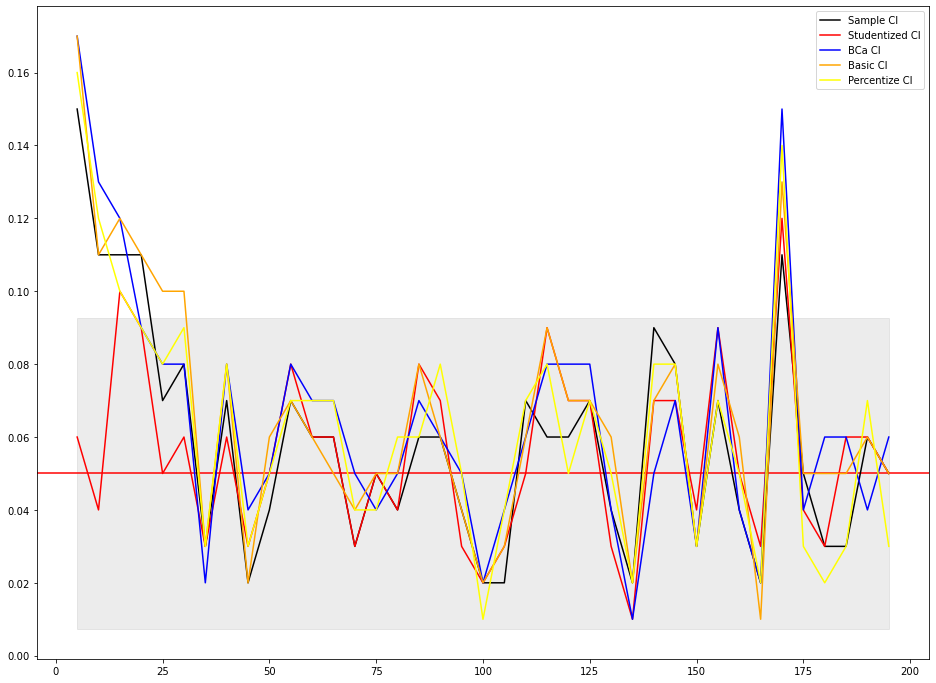

In [57]:
coverage_ci = proportion_confint(n_sim*0.05, n_sim, alpha=0.05)
plt.figure(figsize=(16,12))
plt.axhline(y=0.05, color = 'red')
plt.fill_between(sample_size_list, coverage_ci[0], coverage_ci[1], color='gray', alpha=.15)
sns.lineplot(x = sample_size_list, y = bad_sample_ci_count_list, color = 'black', label = 'Sample CI')
sns.lineplot(x = sample_size_list, y = bad_stud_ci_count_list, color = 'red', label = 'Studentized CI')
sns.lineplot(x = sample_size_list, y = bad_bca_ci_count_list, color = 'blue', label = 'BCa CI')
sns.lineplot(x = sample_size_list, y = bad_basic_ci_count_list, color = 'orange', label = 'Basic CI')
sns.lineplot(x = sample_size_list, y = bad_perc_ci_count_list, color = 'yellow', label = 'Percentize CI')

Видим, что на маленьких выборках (меньше 15 наблюдений) бутстрап стабильно выбивается из доверительного интервала.
Также видим, что bootstrap-t вариант подсчета ДИ справляется лучше других на маленьких объемах выборки.

Как мы видим, бутстрапированные доверительные интервалы для средней, взятой из нормально рапределенных выборок, показывают себя не намного хуже, чем выборочные доверительные интервалы.

Давайте посмотрим, как будут вести себя интервалы на ненормально распределенных выборках.

In [59]:
sample_size_list = np.arange(5, 200, 5)
n_resamples = 500 # кол-во resample выборок в одной итерации бутстрапа
n_sim = 100 # кол-во симуляций бутстрапа для одного рамера выборки

bad_perc_ci_count_list = []
bad_basic_ci_count_list = []
bad_bca_ci_count_list = []
bad_stud_ci_count_list = []
bad_sample_ci_count_list = []

scale = 100
for i in tqdm(sample_size_list):
    
    bad_perc_ci_count = 0
    bad_basic_ci_count = 0
    bad_bca_ci_count = 0
    bad_stud_ci_count = 0
    bad_sample_ci_count = 0
    
    
    for j in range(n_sim):
        first_sample_data = np.random.exponential(scale = scale, size = i)
        
        perc_ci = bootstrap((first_sample_data,), n_resamples = n_resamples, statistic = np.mean, confidence_level = 0.95, method = 'percentile').confidence_interval
        bad_perc_ci_count += np.sum(((perc_ci[0] >= scale) | (perc_ci[1] <= scale)))
        
        basic_ci = bootstrap((first_sample_data,), n_resamples = n_resamples, statistic = np.mean, confidence_level = 0.95, method = 'basic').confidence_interval
        bad_basic_ci_count += np.sum(((basic_ci[0] >= scale) | (basic_ci[1] <= scale)))
        
        bca_ci = bootstrap((first_sample_data,), n_resamples = n_resamples, statistic = np.mean, confidence_level = 0.95, method = 'BCa').confidence_interval
        bad_bca_ci_count += np.sum(((bca_ci[0] >= scale) | (bca_ci[1] <= scale)))
        
        stud_ci = get_studentized_ci_full(first_sample_data, n_resamples, np.mean, 0.05)
        bad_stud_ci_count += np.sum(((stud_ci[0] >= scale) | (stud_ci[1] <= scale)))
        
        sample_ci = get_sample_mean_ci(first_sample_data, 0.05)
        bad_sample_ci_count += np.sum(((sample_ci[0] >= scale) | (sample_ci[1] <= scale)))
    
    
    bad_perc_ci_count_list.append(bad_perc_ci_count/n_sim)
    bad_basic_ci_count_list.append(bad_basic_ci_count/n_sim)
    bad_bca_ci_count_list.append(bad_bca_ci_count/n_sim)
    bad_stud_ci_count_list.append(bad_stud_ci_count/n_sim)
    bad_sample_ci_count_list.append(bad_sample_ci_count/n_sim)

  0%|                                                                                           | 0/39 [00:00<?, ?it/s]C:\Users\kazakov\AppData\Local\Temp/ipykernel_18756/1989923067.py:11: RuntimeWarning: divide by zero encountered in true_divide
  t_statistics = (resampled_stats - sample_stat) / resample_std_errs
100%|██████████████████████████████████████████████████████████████████████████████████| 39/39 [00:22<00:00,  1.77it/s]


<AxesSubplot:>

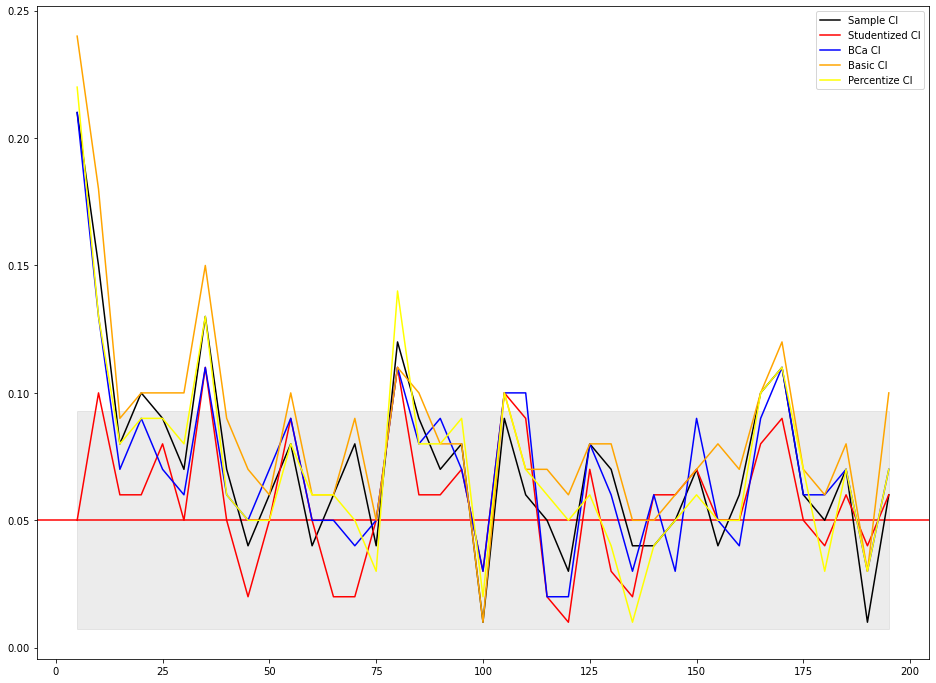

In [61]:
coverage_ci = proportion_confint(n_sim*0.05, n_sim, alpha=0.05)
plt.figure(figsize=(16,12))
plt.axhline(y=0.05, color = 'red')
plt.fill_between(sample_size_list, coverage_ci[0], coverage_ci[1], color='gray', alpha=.15)
sns.lineplot(x = sample_size_list, y = bad_sample_ci_count_list, color = 'black', label = 'Sample CI')
sns.lineplot(x = sample_size_list, y = bad_stud_ci_count_list, color = 'red', label = 'Studentized CI')
sns.lineplot(x = sample_size_list, y = bad_bca_ci_count_list, color = 'blue', label = 'BCa CI')
sns.lineplot(x = sample_size_list, y = bad_basic_ci_count_list, color = 'orange', label = 'Basic CI')
sns.lineplot(x = sample_size_list, y = bad_perc_ci_count_list, color = 'yellow', label = 'Percentize CI')

Как мы видим, и для ненормално распределенных данных доверительные интервалы оценки средней через бутстрап довольно стабильно попадают в нужные доверительные интервалы покрываемости. При этом на небольших выборках (меньше 50 наблюдений) предпочтительнее использовать bootstrap-t, т.к. покрываемость у него чуть лучше, чем у других способов построить ДИ.

## Проверка гипотез с помощью бутстрапа

Давайте посмотрим логику проверки гипотез с помощью бутстрапа на модельных данных. Для начала рассмотрим красивые нормальные данные.

Effect size = 0.1
Mean lift = 5.0
Sample size = 1570


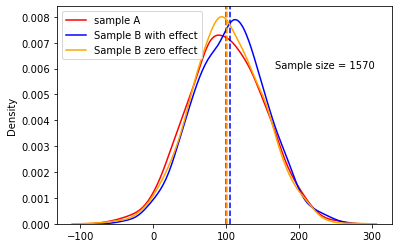

In [65]:
# зададим исходные параметры распределений и определим нужный размер выборок 
lift = 0.05
alpha = 0.05
beta = 0.2
std = 50
mean = 100
power = 1 - beta
lift = 0.05 # хотим увидеть 5% изменение в метрике (тоже самое что чувствительность, MDE)
effect_size = mean * lift / std # 

print('Effect size =', effect_size)
print('Mean lift =', mean*lift)

sample_size = int(tt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=power, nobs1=None, ratio=1))
print('Sample size =', sample_size)

# создадим выборки: ААБ
# пример с нормальным распределением
sample_B_with_effect = np.random.normal(mean*(1+lift), std, sample_size)
sample_B_zero_effect = np.random.normal(mean, std, sample_size)
sample_A = np.random.normal(mean, std, sample_size)

# посмотрим, как выглядят полученные данные
sns.kdeplot(sample_A, color = 'red', label="sample A")
plt.axvline(sample_A.mean(), color = 'red', linestyle ='--')
sns.kdeplot(sample_B_with_effect, color = 'blue', label="Sample B with effect")
plt.axvline(sample_B_with_effect.mean(), color = 'blue', linestyle ='--')
sns.kdeplot(sample_B_zero_effect, color = 'orange', label="Sample B zero effect")
plt.axvline(sample_B_zero_effect.mean(), color = 'orange', linestyle ='--')
plt.text(np.quantile(sample_A, 0.9), 0.006, 'Sample size = {}'.format(sample_size))
plt.legend()

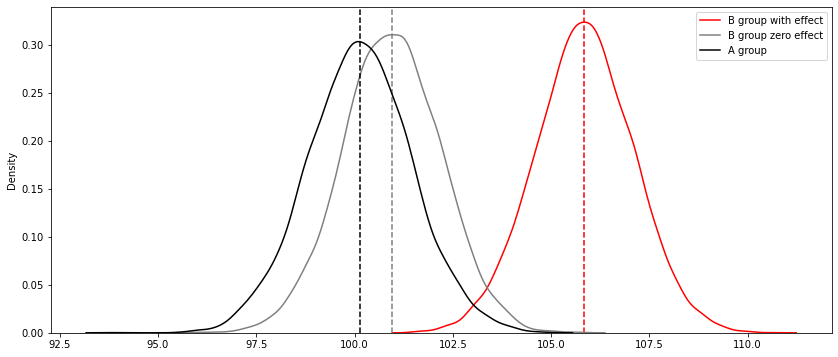

In [66]:
#получим бутстрапированные статистики (например, среднюю)
n_resamples = 10000

# получаем бутстрапированные данные
resampled_data_A = get_resampled_data(sample_A, len(sample_A), n_resamples)
resampled_data_B_zero_effect = get_resampled_data(sample_B_zero_effect, len(sample_B_zero_effect), n_resamples)
resampled_data_B_with_effect = get_resampled_data(sample_B_with_effect, len(sample_B_with_effect), n_resamples)

# получаем бутстрапированные статистики
resampled_stats_A = get_resampled_stats(resampled_data_A, np.mean)
resampled_stats_B_zero_effect = get_resampled_stats(resampled_data_B_zero_effect, np.mean)
resampled_stats_B_with_effect = get_resampled_stats(resampled_data_B_with_effect, np.mean)

# посмотрим, что получилось
plt.figure(figsize=(14,6))
sns.kdeplot(resampled_stats_B_with_effect, label = 'B group with effect', color = 'red')
plt.axvline(x = resampled_stats_B_with_effect.mean(), linestyle = '--', color = 'red')
sns.kdeplot(resampled_stats_B_zero_effect, label = 'B group zero effect', color = 'gray')
plt.axvline(x = resampled_stats_B_zero_effect.mean(), linestyle = '--', color = 'gray')
sns.kdeplot(resampled_stats_A, label = 'A group', color = 'black')
plt.axvline(x = resampled_stats_A.mean(), linestyle = '--', color = 'black')
plt.legend()

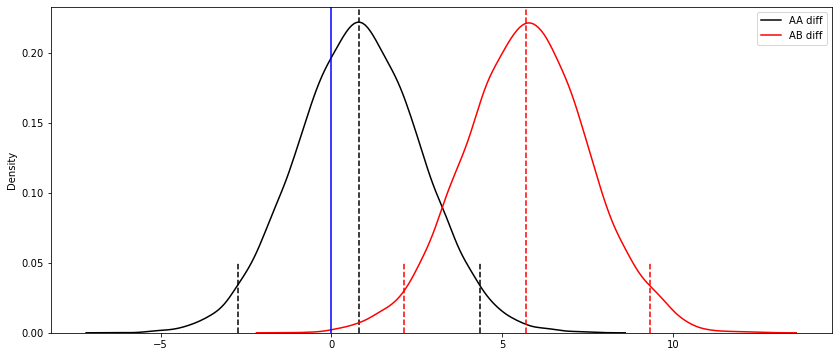

In [67]:
# построим распределения разниц статистики (АА и АБ) полученные из бутстрапа
# и построим доверительные интервалы

# получим точечную разницу средних между соответствующими группами (одно число)
aa_sample_mean_diff = sample_A.mean()-sample_B_zero_effect.mean()
ab_sample_mean_diff = sample_A.mean()-sample_B_with_effect.mean()

# получим вектор разниц средних между соответствующими группами 
aa_means_diff = resampled_stats_B_zero_effect - resampled_stats_A
ab_means_diff = resampled_stats_B_with_effect - resampled_stats_A

# перцентильный интервал для средних
alpha = 0.05
aa_perc_ci = np.quantile(aa_means_diff, [alpha/2, 1-alpha/2])
ab_perc_ci = np.quantile(ab_means_diff, [alpha/2, 1-alpha/2])

# Нарисуем, что получилось и покажем границы интервала. И посмотрим, как далеко разница средних находится от 0.
# АА-проверка
plt.figure(figsize=(14,6))
sns.kdeplot(aa_means_diff, color = 'black', label = 'AA diff')
plt.axvline(x = aa_means_diff.mean(), linestyle = '--', color = 'black')
plt.vlines(aa_perc_ci, ymin = 0, ymax= 0.05, linestyle = '--', color = 'black')

# АБ-проверка
sns.kdeplot(ab_means_diff, color = 'red', label = 'AB diff')
plt.axvline(x = ab_means_diff.mean(), linestyle = '--', color = 'red')
plt.axvline(x = 0, color = 'blue')
plt.vlines(x = ab_perc_ci, ymin = 0, ymax= 0.05, linestyle = '--', color = 'red')
plt.legend()

Как видно из графика, в АА тесте доверительный интервал содержит ноль, а в АБ тесте 0 находится довольно далеко в левом хвосте.
Это позволяет нам корректно проверить наши гипотезы.
По сути проверка гипотезы заключается в попытке проверить, попадает ли 0 в критические значения для распределения (в ДИ)

### Расчет p-value в бутстрапе

Иногда удобно оперировать не просто фактом, накрыл ли ДИ 0 или нет, а конкретной вероятностью получить такие или еще большие различия при верной гипотезе H0. Т.е. уметь находить p-value. Давайте научимся находить p-value в бутстрапе.

AA Sample diff = 0.659998248821509
AB Sample diff = -6.242004058435512
AA p-value = 0.7125
AB p-value = 0.0004


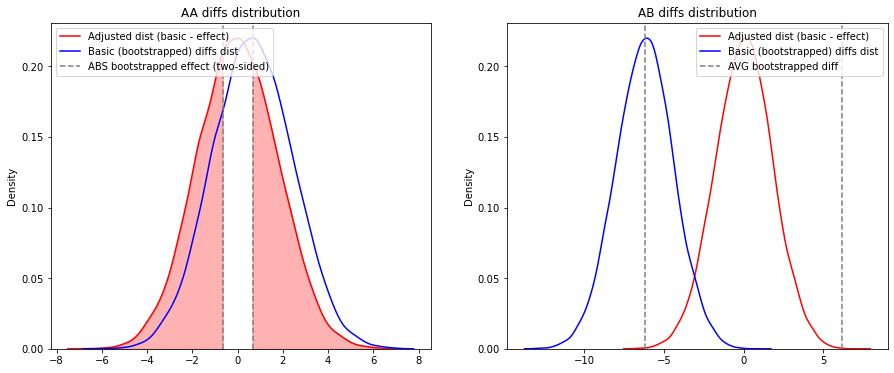

In [39]:
# построим распределения разниц статистики, полученные из бутстрапа и найдем p-value 
aa_sample_mean_diff = sample_A.mean() - sample_B_zero_effect.mean() # найдем эффект между выборочными статистиками
ab_sample_mean_diff = sample_A.mean() - sample_B_with_effect.mean()

aa_means_diff = resampled_stats_A - resampled_stats_B_zero_effect # найдем эффект в каждой итерации бутстрапа
ab_means_diff = resampled_stats_A - resampled_stats_B_with_effect

aa_t = aa_means_diff - aa_sample_mean_diff # вычитаем из каждого бутстрапированного эффекта генеральный эффект (превращаем наше распределение в H0, сдвигаем всё распределение ближе к 0)
ab_t = ab_means_diff - ab_sample_mean_diff

# рассчитываем p-value 
aa_count = np.sum(np.abs(aa_t) >= np.abs(aa_sample_mean_diff)) # считаем в скольких случаях наш эффект по модулю больше генерального
ab_count = np.sum(np.abs(ab_t) >=  np.abs(ab_sample_mean_diff))
aa_p_value = aa_count / n_resamples
ab_p_value = ab_count / n_resamples
alpha = 0.05

fig, axes = plt.subplots(1, 2, figsize=(15,6))

# рисуем распределения для АA тестирования
axes[0].set_title('AA diffs distribution')
sns.kdeplot(ax=axes[0], data = aa_t, label = "Adjusted dist (basic - effect)", color = 'red')
sns.kdeplot(ax=axes[0], data = aa_means_diff, label = "Basic (bootstrapped) diffs dist", color = 'blue')
axes[0].axvline(x=aa_means_diff.mean(), linestyle = '--', color = 'gray', label = "ABS bootstrapped effect (two-sided)")
axes[0].axvline(x=-aa_means_diff.mean(), linestyle = '--', color = 'gray')
# закрасим область функции плотности распределения, при которых мы получаем такие или еще более ярко выраженные различия
aa_kde = gaussian_kde(aa_t)
shade_right = np.linspace(np.abs(aa_sample_mean_diff), aa_t.max(), 101)
shade_left = np.linspace(aa_t.min(), -np.abs(aa_sample_mean_diff), 101)
axes[0].fill_between(shade_right, aa_kde(shade_right), color = 'red', alpha=0.3)
axes[0].fill_between(shade_left, aa_kde(shade_left), color = 'red', alpha=0.3)
axes[0].legend(loc='upper left')

# рисуем распределения для АБ тестирования
axes[1].set_title('AB diffs distribution')
sns.kdeplot(ax=axes[1], data = ab_t, label = "Adjusted dist (basic - effect)", color = 'red')
sns.kdeplot(ax=axes[1], data = ab_means_diff, label = "Basic (bootstrapped) diffs dist", color = 'blue')
axes[1].axvline(x=ab_means_diff.mean(), linestyle = '--', color = 'gray', label = 'AVG bootstrapped diff')
axes[1].axvline(x=-ab_means_diff.mean(), linestyle = '--', color = 'gray')
# закрасим область функции плотности распределения, при которых мы получаем такие или еще более ярко выраженные различия
ab_kde = gaussian_kde(ab_t)
shade_right = np.linspace(np.abs(ab_sample_mean_diff), ab_t.max(), 101)
shade_left = np.linspace(ab_t.min(), -np.abs(ab_sample_mean_diff), 101)
axes[1].fill_between(shade_right, ab_kde(shade_right), color = 'red', alpha=0.3)
axes[1].fill_between(shade_left, ab_kde(shade_left), color = 'red', alpha=0.3)
axes[1].legend(loc='upper right')

print('AA Sample diff =', aa_sample_mean_diff)
print('AB Sample diff =', ab_sample_mean_diff)
print('AA p-value =', aa_p_value)
print('AB p-value =', ab_p_value)

Как мы видим, на графиках в случае АА-тестирования гипотезы большая часть графика плотности (большая часть вероятности) закрашена. Что говорит, что получить такие или еще большие различия получить достаточно вероятно. Т.е. p-value достаточно большой.
В кейсе АБ-тестирования наоборот - "закрашенная" вероятность очень небольшая. Что соответствует низкому p-value и стат значимости различий.

## Давайте упакуем проверку гипотез через бутстрап в удобные функции

In [17]:
def get_perc_ci(resampled_stats, alpha):
    left, right = np.quantile(resampled_stats, [alpha / 2, 1 - alpha / 2])
    return (left, right)

In [18]:
def get_basic_ci(first_sample_data, resampled_stats, alpha, stat):
    left, right = 2 * stat(first_sample_data) - np.quantile(resampled_stats, [1 - alpha / 2,  alpha / 2])
    return (left, right)

In [70]:
def bootstrap_ab_test(sample_data_A, sample_data_B, stat, resample_num, alpha, q):
    '''
    sample_data_A - значения в выборке А
    sample_data_B - значения в выборке B
    stat - можно передать оцениваемую функцию
    resample_num - количество итераций извлечения resample выборок в бутстрапе
    alpha - уровень значимости при проверке
    q - указывается если вы оцениваете определенный квантиль распределения
    
    '''
    # получаем бутстрапированные данные
    resampled_data_A = get_resampled_data(sample_data_A, len(sample_data_A), resample_num)
    resampled_data_B = get_resampled_data(sample_data_B, len(sample_data_B), resample_num)
    
    if q is not None:
        resampled_stats_A = get_resampled_quantile(resampled_data_A, q)
        resampled_stats_B = get_resampled_quantile(resampled_data_B, q)
    else:
        resampled_stats_A = get_resampled_stats(resampled_data_A, stat)
        resampled_stats_B = get_resampled_stats(resampled_data_B, stat)
    
    # рассчитываем разницу для статистики
    resampled_diffs = resampled_stats_B - resampled_stats_A
    
    # рассчитываем перцентильный бутстрап
    perc_ci = np.quantile(resampled_diffs, [alpha/2, 1-alpha/2])
    
    if q is not None:
        samples_diff = np.quantile(sample_data_B, q) - np.quantile(sample_data_A, q)
    else:
        samples_diff = stat(sample_data_B) - stat(sample_data_A)
    
    # рассчитываем p-value
    adjusted_resampled_diffs = resampled_diffs - samples_diff
    false_positive_count = np.sum(np.abs(adjusted_resampled_diffs) >= np.abs(samples_diff))
    p_value = false_positive_count / resample_num
    
    # формируем результат
    boot_data_object = {'resample_stats_A':resampled_stats_A,
                         'resample_stats_B':resampled_stats_B,
                         'resampled_diffs': resampled_diffs,
                         'conf_int': perc_ci,
                         'stat_diffs_std': resampled_diffs.std(),
                         'p_value': p_value}  
    return(boot_data_object)

In [ ]:
bootstrap_ab_test()

In [69]:
# также сделаем функцию, отрисовывающую результат проверки гипотез через бутстрап
def boot_data_plot(boot_data_object):
    fig, axes = plt.subplots(1, 2, figsize = (15,6))

    axes[0].set_title('A & B botstraped stats distribution')
    sns.kdeplot(ax = axes[0], data = boot_data_object['resample_stats_A'], label = "resample_stats_A", color = 'blue')
    axes[0].axvline(x = boot_data_object['resample_stats_A'].mean(), linestyle = '--', color = 'blue')
    sns.kdeplot(ax = axes[0], data = boot_data_object['resample_stats_B'], label = "resample_stats_B", color = 'red')
    axes[0].axvline(x = boot_data_object['resample_stats_B'].mean(), linestyle = '--', color = 'red')
    axes[0].legend(loc='upper right')

    axes[1].set_title('A & B botstraped stats diffs distribution')
    sns.kdeplot(ax=axes[1], data = boot_data_object['resampled_diffs'], label = "resample_stats_diffs", color = 'black')
    axes[1].axvline(x = 0, color = 'red')
    axes[1].axvline(x = boot_data_object['resampled_diffs'].mean(), linestyle = '--', color = 'black')
    axes[1].vlines(boot_data_object['conf_int'], ymin = 0, ymax= 0.05, linestyle = '-', color = 'black')
    axes[1].legend(loc='upper right')
    
    # сделаем часть, которая принтует основные значения и вывод по проверке гипотез
    if boot_data_object['p_value'] < alpha:
        conclusion = 'H0 rejected!!!'
    else:
        conclusion = "H0 doesn't rejected!!!"

    print(conclusion)
    print('A sample stat mean =', boot_data_object['resample_stats_A'].mean())
    print('B sample stat mean =', boot_data_object['resample_stats_B'].mean())
    print('Avg lift =', boot_data_object['resampled_diffs'].mean())
    print('p-val =', boot_data_object['p_value'])
    print('Diffs ci:', boot_data_object['conf_int'])
    print('stats diffs std = ', boot_data_object['stat_diffs_std'])

H0 doesn't rejected!!!
A sample stat mean = 100.1520728824354
B sample stat mean = 100.96652365550382
Avg lift = 0.8144507730684265
p-val = 0.6539
Diffs ci: [-2.75795482  4.41678903]
stats diffs std =  1.8203875314794116


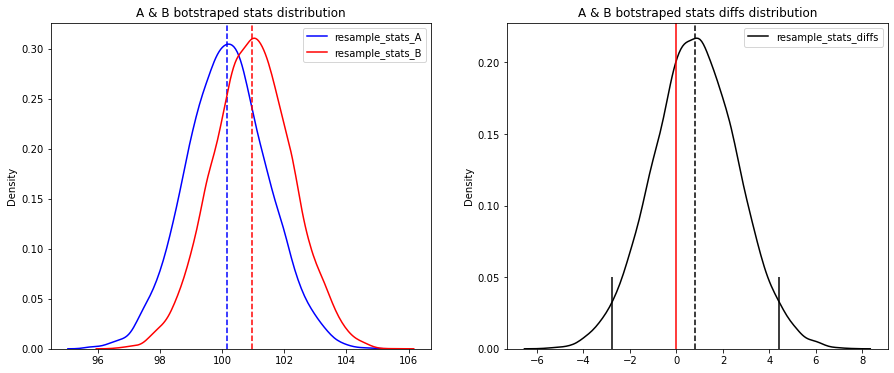

In [71]:
# посмотрим, как выглядит проверка гипотезы о равенстве средних в группах, где нет эффекта
boot_data = bootstrap_ab_test(sample_data_A = sample_A,
    sample_data_B = sample_B_zero_effect,
    stat = np.mean,
    resample_num = 10000,
    alpha = 0.05,
    q = None)

boot_data_plot(boot_data)

H0 rejected!!!
A sample stat mean = 100.13993623629305
B sample stat mean = 105.87770301231062
Avg lift = 5.737766776017552
p-val = 0.0019
Diffs ci: [2.24829005 9.27239062]
stats diffs std =  1.7931559525193983


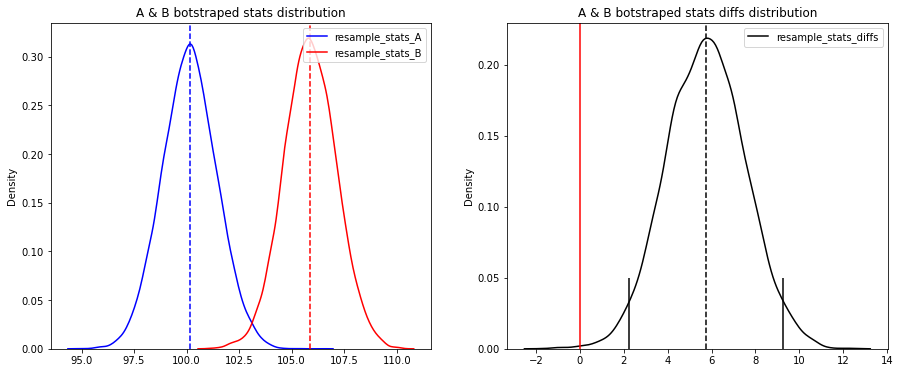

In [72]:
# посмотрим, как выглядит проверка гипотезы о равенстве средних в группах, где есть эффект
boot_data = bootstrap_ab_test(sample_data_A = sample_A,
    sample_data_B = sample_B_with_effect,
    stat = np.mean,
    resample_num = 10000,
    alpha = 0.05,
    q = None)

boot_data_plot(boot_data)

In [57]:
boot_data

{'resample_stats_A': array([ 98.59622621,  97.53089722,  99.15635698, ..., 100.81104706,
         99.03022804,  97.67731208]),
 'resample_stats_B': array([107.54423828, 103.21201914, 104.64579366, ..., 104.38597727,
        105.68596624, 104.61307066]),
 'resampled_diffs': array([8.94801206, 5.68112193, 5.48943668, ..., 3.57493021, 6.6557382 ,
        6.93575858]),
 'conf_int': array([2.71990073, 9.77311364]),
 'stat_diffs_std': 1.80190455586482,
 'p_value': 0.0009}

# Проверим бутстрап как способ проверки гипотез на его способность выдерживать уровни ошибок первого и второго уровня

### Нам нужна функция, которую мы использовали раньше для отрисовки результатов симуляции.

In [73]:
def experiment_simulation_plot(alpha, aa_control_group_means, aa_test_group_means, aa_means_diffs_list, aa_stat_list, aa_p_val_list, ab_control_group_means, ab_test_group_means, ab_means_diffs_list, ab_stat_list, ab_p_val_list):   
    #confidence_interval for alpha & beta
    alpha_ci = proportion_confint(np.sum(np.array(aa_p_val_list) < alpha), n_iter, alpha=0.05)
    beta_ci = proportion_confint(np.sum(np.array(ab_p_val_list) < alpha), n_iter, alpha=0.05)
    
    # PLOT
    fig, axes = plt.subplots(2, 4, figsize=(15,10))

    # AA subplots

    sns.kdeplot(ax=axes[0,0], data = aa_control_group_means, color = 'blue')
    sns.kdeplot(ax=axes[0,0], data = aa_test_group_means, color = 'red')
    axes[0,0].set_title('AA: A|B group mean distribution')
    axes[0,0].axvline(x=np.quantile(aa_control_group_means, 0.5), linestyle = '--', color = 'blue', label = 'control mean')
    axes[0,0].axvline(x=np.quantile(aa_test_group_means, 0.5), linestyle = '--', color = 'red', label = 'test mean')
    axes[0,0].legend(loc='lower right')

    sns.kdeplot(ax=axes[0,1], data = aa_means_diffs_list)
    axes[0,1].axvline(x=0, linestyle = '--', color = 'red', label = 'zero difference')
    axes[0,1].axvline(x=np.quantile(aa_means_diffs_list, alpha/2), linestyle = '--', color = 'grey', label = '95% conf interval for diff')
    axes[0,1].axvline(x=np.quantile(aa_means_diffs_list, 1-alpha/2), linestyle = '--', color = 'grey')
    axes[0,1].set_title('AA: Means diffs distribution')
    axes[0,1].legend(loc='lower right')

    sns.kdeplot(ax=axes[0,2], data = aa_stat_list)
    axes[0,2].set_title('AA: stats distribution')

    sns.kdeplot(ax=axes[0,3], data = aa_p_val_list)
    axes[0,3].set_title('AA: p-values distribution')
    axes[0,3].axvline(x=alpha, linestyle = '--', color = 'red', label = 'alpha')
    axes[0,3].axvline(x=np.quantile(aa_p_val_list, 0.8), linestyle = '--', color = 'blue', label = '80% quantile for p-value')
    axes[0,3].legend(loc='lower right')

    #AB subplots
    sns.kdeplot(ax=axes[1,0], data = ab_control_group_means, color = 'blue')
    sns.kdeplot(ax=axes[1,0], data = ab_test_group_means, color = 'red')
    axes[1,0].set_title('AB: A|B group mean distribution')
    axes[1,0].axvline(x=np.quantile(ab_control_group_means, 0.5), linestyle = '--', color = 'blue', label = 'control mean')
    axes[1,0].axvline(x=np.quantile(ab_test_group_means, 0.5), linestyle = '--', color = 'red', label = 'test mean')
    axes[1,0].legend(loc='lower right')

    sns.kdeplot(ax=axes[1,1], data = ab_means_diffs_list)
    axes[1,1].axvline(x=0, linestyle = '--', color = 'red', label = 'zero difference')
    axes[1,1].axvline(x=np.quantile(ab_means_diffs_list, alpha/2), linestyle = '--', color = 'grey', label = '95% conf interval for diff')
    axes[1,1].axvline(x=np.quantile(ab_means_diffs_list, 1-alpha/2), linestyle = '--', color = 'grey')
    axes[1,1].set_title('AB: Means diffs distribution')
    axes[1,1].legend(loc='lower right')

    sns.kdeplot(ax=axes[1,2], data = ab_stat_list)
    axes[1,2].set_title('AB: stats distribution')

    sns.kdeplot(ax=axes[1,3], data = ab_p_val_list)
    axes[1,3].set_title('AB: p-values distribution')
    axes[1,3].axvline(x=alpha, linestyle = '--', color = 'red', label = 'alpha')
    axes[1,3].axvline(x=np.quantile(ab_p_val_list, 0.8), linestyle = '--', color = 'blue', label = '80% quantile for p-value')
    axes[1,3].legend(loc='lower right')

    print('Median means lift for AA simulation = ', np.median(aa_means_diffs_list))
    print('Alpha(FPR) = ', np.sum(np.array(aa_p_val_list) < alpha) / n_iter)
    print('Alpha 95% CI:', alpha_ci)
    print('Median means lift for AB simulation = ', np.median(ab_means_diffs_list))
    print('Power(TPR) = ', np.sum(np.array(ab_p_val_list) < alpha) / n_iter)
    print('Beta 95% CI:', beta_ci)

### для сравнения посмотрим на t-test

Effect size = 0.05
Estimated absolute effect = 5.0
Number of simulations =  1000
Sample size =  6280
Median means lift for AA simulation =  0.05836985496959102
Alpha(FPR) =  0.041
Alpha 95% CI: (0.028710072442407468, 0.053289927557592535)
Median means lift for AB simulation =  5.056197605339754
Power(TPR) =  0.791
Beta 95% CI: (0.7657994815375094, 0.8162005184624906)


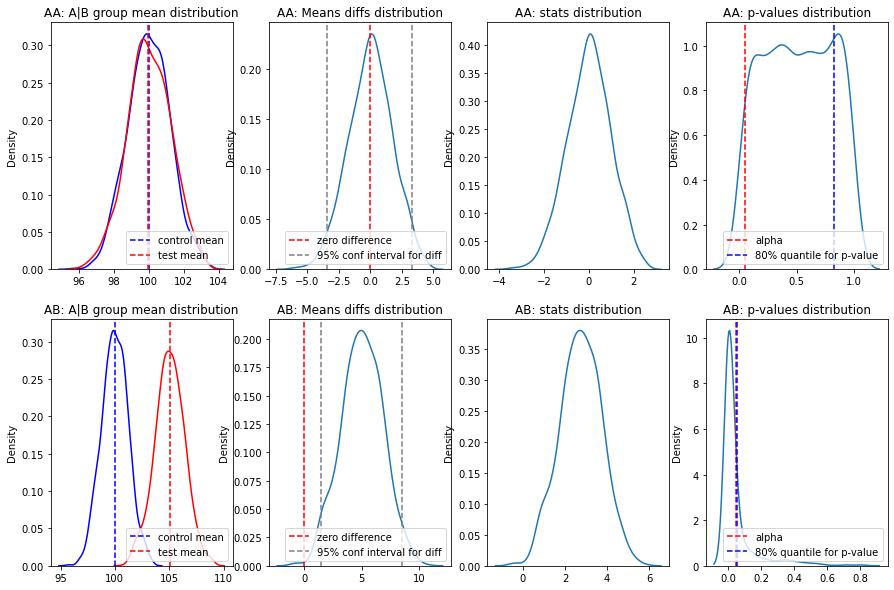

In [75]:
# определим дизайн теста
alpha = 0.05
beta = 0.2

sigma_1 = 100
std = sigma_1
power = 1 - beta
rel_lift = 0.05
abs_lift = sigma_1*rel_lift #
effect_size = abs_lift / std

print('Effect size =', effect_size)
print('Estimated absolute effect =', abs_lift)

n_iter = 1000
print('Number of simulations = ', n_iter)

sample_size = int(tt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=power, nobs1=None, ratio=1))
print('Sample size = ', sample_size)

aa_control_group_means = []
aa_test_group_means = []
ab_control_group_means = []
ab_test_group_means = []

aa_p_val_list = []
aa_t_stat_list = []
aa_means_diffs_list = []

ab_p_val_list = []
ab_t_stat_list = []
ab_means_diffs_list = []

for i in range(n_iter):
      
    sample_1 = np.random.exponential(scale= sigma_1, size=sample_size)
    sample_2_zero_effect = np.random.exponential(scale= sigma_1+0, size=sample_size)
    sample_2_with_effect = np.random.exponential(scale= sigma_1+sigma_1*rel_lift, size=sample_size)
    
    aa_control_group_means.append(sample_1.mean())
    aa_test_group_means.append(sample_2_zero_effect.mean())
    ab_control_group_means.append(sample_1.mean())
    ab_test_group_means.append(sample_2_with_effect.mean())

    aa_means_diff = sample_2_zero_effect.mean() - sample_1.mean()
    ab_means_diff = sample_2_with_effect.mean() - sample_1.mean()
    
    aa_t_stat, aa_p_val = ttest_ind(sample_2_zero_effect, sample_1)
    ab_t_stat, ab_p_val = ttest_ind(sample_2_with_effect, sample_1)
    
    aa_p_val_list.append(aa_p_val)
    ab_p_val_list.append(ab_p_val)
    
    aa_t_stat_list.append(aa_t_stat)
    ab_t_stat_list.append(ab_t_stat)
    
    aa_means_diffs_list.append(aa_means_diff)
    ab_means_diffs_list.append(ab_means_diff)
    
experiment_simulation_plot(alpha = 0.05,
                           aa_control_group_means = aa_control_group_means,
                           aa_test_group_means = aa_test_group_means,
                           aa_means_diffs_list = aa_means_diffs_list,
                           aa_stat_list = aa_t_stat_list,
                           aa_p_val_list = aa_p_val_list,
                           ab_control_group_means = ab_control_group_means,
                           ab_test_group_means = ab_test_group_means,
                           ab_means_diffs_list = ab_means_diffs_list,
                           ab_stat_list = ab_t_stat_list,
                           ab_p_val_list = ab_p_val_list)

Effect size = 0.05
Estimated absolute effect = 5.0
Number of simulations =  300
Sample size =  6280


100%|████████████████████████████████████████████████████████████████████████████████| 300/300 [02:11<00:00,  2.29it/s]
C:\Users\kazakov\AppData\Local\Temp/ipykernel_18756/22141617.py:25: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(ax=axes[0,2], data = aa_stat_list)
C:\Users\kazakov\AppData\Local\Temp/ipykernel_18756/22141617.py:49: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(ax=axes[1,2], data = ab_stat_list)


Median means lift for AA simulation =  0.25124525981500767
Alpha(FPR) =  0.03
Alpha 95% CI: (0.010696593419623306, 0.04930340658037669)
Median means lift for AB simulation =  5.055446650320192
Power(TPR) =  0.79
Beta 95% CI: (0.7439095809539136, 0.8360904190460865)


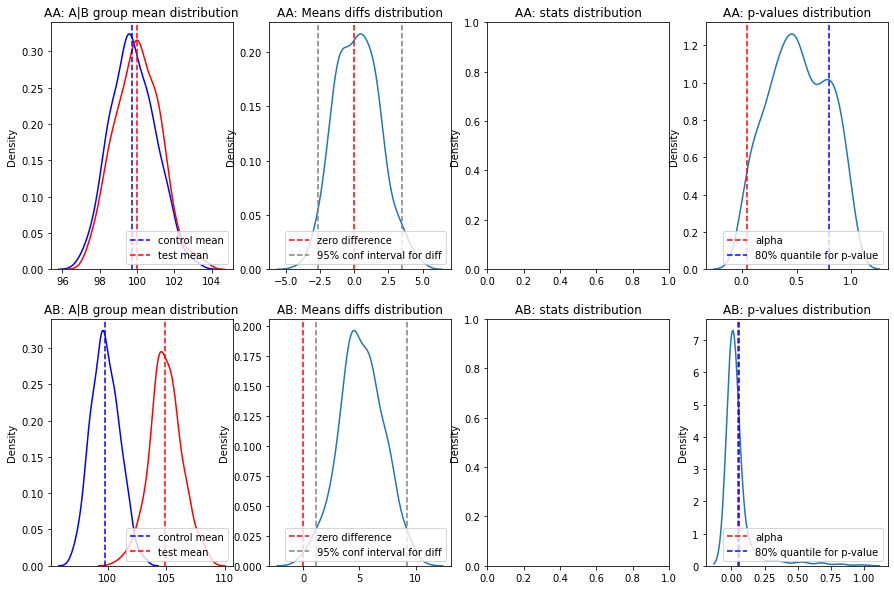

In [76]:
# определим дизайн теста
alpha = 0.05
beta = 0.2

sigma_1 = 100
std = sigma_1
power = 1 - beta
rel_lift = 0.05
abs_lift = sigma_1*rel_lift #
effect_size = abs_lift / std

print('Effect size =', effect_size)
print('Estimated absolute effect =', abs_lift)

n_iter = 300
print('Number of simulations = ', n_iter)

sample_size = int(tt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=power, nobs1=None, ratio=1))
print('Sample size = ', sample_size)

aa_control_group_means = []
aa_test_group_means = []
ab_control_group_means = []
ab_test_group_means = []

aa_p_val_list = []
aa_t_stat_list = []
aa_means_diffs_list = []

ab_p_val_list = []
ab_t_stat_list = []
ab_means_diffs_list = []

for i in tqdm(range(n_iter)):
      
    sample_1 = np.random.exponential(scale= sigma_1, size=sample_size)
    sample_2_zero_effect = np.random.exponential(scale= sigma_1+0, size=sample_size)
    sample_2_with_effect = np.random.exponential(scale= sigma_1+sigma_1*rel_lift, size=sample_size)
    
    aa_control_group_means.append(sample_1.mean())
    aa_test_group_means.append(sample_2_zero_effect.mean())
    ab_control_group_means.append(sample_1.mean())
    ab_test_group_means.append(sample_2_with_effect.mean())

    aa_means_diff = sample_2_zero_effect.mean() - sample_1.mean()
    ab_means_diff = sample_2_with_effect.mean() - sample_1.mean()
    
    #aa_t_stat, aa_p_val = ttest_ind(sample_2_zero_effect, sample_1)
    #ab_t_stat, ab_p_val = ttest_ind(sample_2_with_effect, sample_1)
    
    aa_boot_data = bootstrap_ab_test(sample_data_A = sample_1,
                                  sample_data_B = sample_2_zero_effect,
                                  stat = np.mean,
                                  resample_num = 1000,
                                  alpha = 0.05, q = None)
    aa_p_val = aa_boot_data['p_value']
    
    ab_boot_data = bootstrap_ab_test(sample_data_A = sample_1,
                                  sample_data_B = sample_2_with_effect,
                                  stat = np.mean,
                                  resample_num = 1000,
                                  alpha = 0.05, q = None)
    ab_p_val = ab_boot_data['p_value']
    
    aa_p_val_list.append(aa_p_val)
    ab_p_val_list.append(ab_p_val)
    
    aa_t_stat_list.append(0) # как таковой статистики критерия в бутстрапе нет, поэтому просто передаем 0 для того, чтобы не ломалась визуализация
    ab_t_stat_list.append(0)
    
    aa_means_diffs_list.append(aa_means_diff)
    ab_means_diffs_list.append(ab_means_diff)
    
experiment_simulation_plot(alpha = 0.05,
                           aa_control_group_means = aa_control_group_means,
                           aa_test_group_means = aa_test_group_means,
                           aa_means_diffs_list = aa_means_diffs_list,
                           aa_stat_list = aa_t_stat_list,
                           aa_p_val_list = aa_p_val_list,
                           ab_control_group_means = ab_control_group_means,
                           ab_test_group_means = ab_test_group_means,
                           ab_means_diffs_list = ab_means_diffs_list,
                           ab_stat_list = ab_t_stat_list,
                           ab_p_val_list = ab_p_val_list)

Как мы видим, для обычного среднего бутстрап показывает сопоставимые с t-test результаты по нужной мощности и статистической значимости. Но применять бутстрап для сравнения средних на нормально распределенных выборках нет никакого смысла. T-test справится тут гораздо быстрее

## Бутстрап для нестандартных кейсов

Мы понимаем, что вся сила бутстрапа в тестировании и интерпретации нестандартных статистик. Например, медиана или квантиль. Давайте покажем, что и тут он справляется достаточно хорошо.

Давате поработаем с более интересными распределениями и реальными кейсами.
Предположим, что мы в классифайде запустили специальные условия на наши услуги, действующие только на верхний средний сегмент платящих пользователей.
И хотим таким образом вырастить ARPU только в определенной группе.

final_ARPU_1 mean = 59.6671
final_ARPU_1_zero_effect mean = 60.825
final_ARPU_2_with_effect mean = 64.0108
AB mean diff 4.3437000000000054
------------------------
final_ARPU_1 0.9 quantile = 249.0
final_ARPU_1_zero_effect 0.9 quantile = 250.0
ARPU_2 0.9 quantile = 273.0499999999993


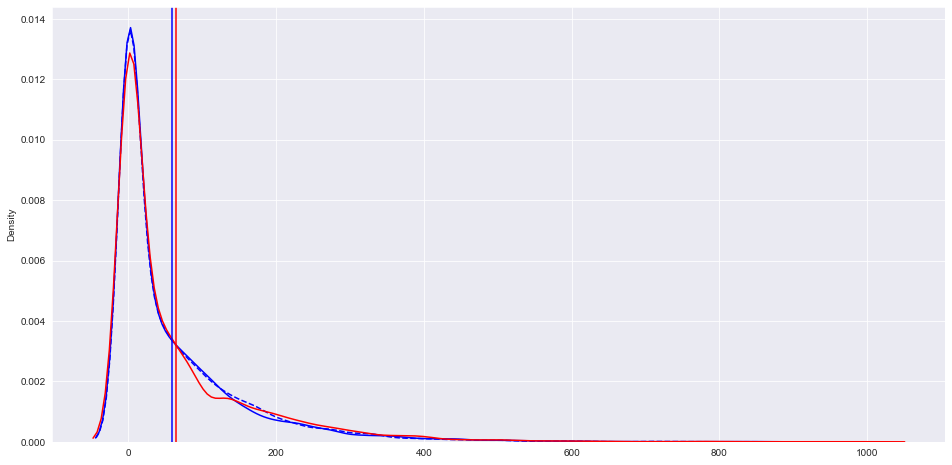

In [126]:
h0_PU_prop = 0.6 # процент платящих по историческим данным
h0_ARPPU = 100 # ARPU по историческим данным
sample_size = 10000
effect = 1.1 # мультипликатор эффект (1 + эффект)
q_effect = 0.79 # с какого квантиля добавляем эффект

# создаем контрольную выборку
all_non_zero_ARPU_1 = np.random.exponential(scale = h0_ARPPU, size = sample_size)
zero_ARPU_mask_1 = np.random.binomial(1, h0_PU_prop , size = sample_size)
final_ARPU_1 = all_non_zero_ARPU_1 * zero_ARPU_mask_1
final_ARPU_1 = np.round(final_ARPU_1, 0) 

# создаем тестовую выборку без эффекта
all_non_zero_ARPU_1_zero_effect = np.random.exponential(scale = h0_ARPPU, size = sample_size)
zero_ARPU_mask_1_zero_effect = np.random.binomial(1, h0_PU_prop, size = sample_size)
final_ARPU_1_zero_effect = all_non_zero_ARPU_1_zero_effect * zero_ARPU_mask_1_zero_effect
final_ARPU_1_zero_effect = np.round(final_ARPU_1_zero_effect, 0)

# создаем тестовую выборку с эффектом, появляющимся только с определенного квантиля
all_non_zero_ARPU_2 = np.random.exponential(scale = h0_ARPPU, size = sample_size)
zero_ARPU_mask_2 = np.random.binomial(1, h0_PU_prop, size = sample_size)
ARPU_2 = zero_ARPU_mask_2 * all_non_zero_ARPU_2
q_effect_level = np.quantile(ARPU_2, q_effect) # определим нужное значение, с которого добавляется эффект
ARPU_2[ARPU_2 >= q_effect_level] = ARPU_2[ARPU_2 >= q_effect_level]* effect # если у пользователя ARPU выше нужного квантиля, добавляем нужный эффект
final_ARPU_2 = np.round(ARPU_2, 0)

# посмотрим, что получилось
plt.figure(figsize=(16,8))
sns.kdeplot(final_ARPU_1, color = 'blue', label = 'final_ARPU_1')
sns.kdeplot(final_ARPU_1_zero_effect, color = 'blue', linestyle = '--', label = 'final_ARPU_1_zero_effect')
sns.kdeplot(final_ARPU_2, color = 'red', label = 'final_ARPU_2')

plt.axvline(x = final_ARPU_2.mean(), color = 'red')
plt.axvline(x = final_ARPU_1.mean(), color = 'blue')

print('final_ARPU_1 mean =', final_ARPU_1.mean())
print('final_ARPU_1_zero_effect mean =', final_ARPU_1_zero_effect.mean())
print('final_ARPU_2_with_effect mean =', final_ARPU_2.mean())
print('AB mean diff', final_ARPU_2.mean() - final_ARPU_1.mean())
print('------------------------')
print('final_ARPU_1 0.9 quantile =', np.quantile(final_ARPU_1, 0.95))
print('final_ARPU_1_zero_effect 0.9 quantile =', np.quantile(final_ARPU_1_zero_effect, 0.95))
print('ARPU_2 0.9 quantile =', np.quantile(final_ARPU_2, 0.95))
# рассчитываем нужные метрики

Видим, что распределения похожи, но красное распределение (там где мы заложии эффект) сдвинулось немного вправо, и там  есть меньше неплатящих пользователей.

C:\Users\kazakov\AppData\Local\Temp/ipykernel_18756/1157655105.py:9: RuntimeWarning: divide by zero encountered in log
  sns.lineplot(x = q, y = np.log(ARPPU_2_q), color = 'red')
C:\Users\kazakov\AppData\Local\Temp/ipykernel_18756/1157655105.py:10: RuntimeWarning: divide by zero encountered in log
  sns.lineplot(x = q, y = np.log(ARPPU_1_q), color = 'gray')
C:\Users\kazakov\AppData\Local\Temp/ipykernel_18756/1157655105.py:11: RuntimeWarning: divide by zero encountered in log
  sns.lineplot(x = q, y = np.log(ARPPU_1_zero_q), color = 'gray')


<AxesSubplot:>

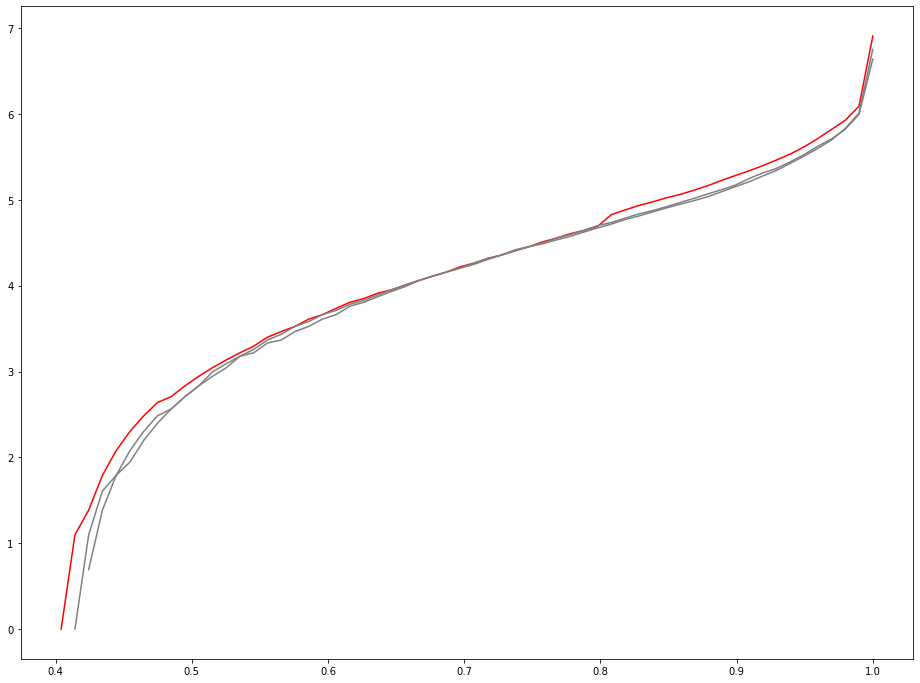

In [78]:
# построим график логарифмированного ARPU. Так нагляднее видно, где именно появился эффект
q = np.linspace(0, 1, 100)
ARPPU_2_q = np.quantile(final_ARPU_2, q)
ARPPU_1_q = np.quantile(final_ARPU_1, q)
ARPPU_1_zero_q = np.quantile(final_ARPU_1_zero_effect, q)

plt.figure(figsize=(16,12))

sns.lineplot(x = q, y = np.log(ARPPU_2_q), color = 'red')
sns.lineplot(x = q, y = np.log(ARPPU_1_q), color = 'gray')
sns.lineplot(x = q, y = np.log(ARPPU_1_zero_q), color = 'gray')

Давайте посмотрим логику проверки гипотез с помощью бутстрапа на реальных данных

H0 doesn't rejected!!!
A sample stat mean = 16.4133
B sample stat mean = 18.0134
Avg lift = 1.6001
p-val = 0.4784
Diffs ci: [-1.  4.]
stats diffs std =  1.4361162870742743


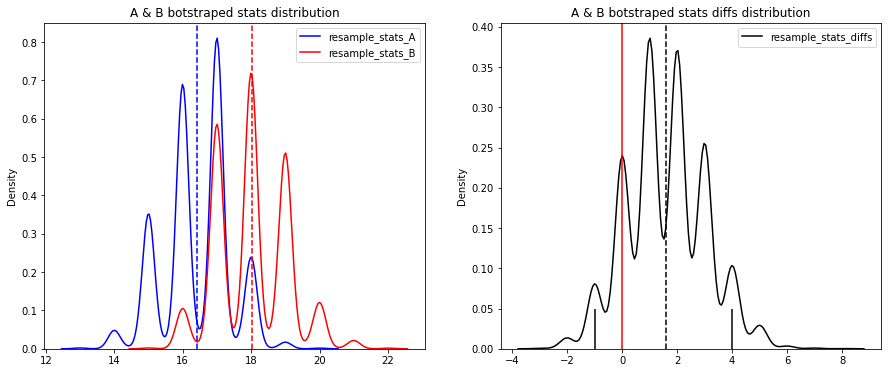

In [80]:
boot_data = bootstrap_ab_test(sample_data_A = final_ARPU_1,
                  sample_data_B = final_ARPU_2,
                  stat = np.median,
                  resample_num = 5000,
                  alpha = 0.05, q = 0.5) # Явно указываем квантиль, который мы хотим проверять q= 0.8. Имейте в виду, что первые 40% пользователей имеют ARPU = 0
boot_data_plot(boot_data)

In [81]:
# давайте построим график p-value, полученных через бутстрап для проверки гипотезы равенства перцентилей каждого перцентиля
peek_num = 9 # кол-во точек наблюдений в линейном пространстве квантилей. Кол-во проверяемых гипотез в пространстве квантилей
perc_linspace = np.linspace(0.05, 1, peek_num)

p_val_list = []
diffs_list = []
lower_ci_list = []
upper_ci_list = []
# для каждого определяемого квантиля проверяем гипотезу о равенстве квантилей с помощью бутстрапа
for i in tqdm(perc_linspace):
    boot_data = bootstrap_ab_test(sample_data_A = final_ARPU_1,
                  sample_data_B = final_ARPU_2,
                  stat = np.mean,
                  resample_num = 1000,
                  alpha = (0.05/peek_num), q = i) # не забываем штрафовать нашу альфа. Пока используем самый простой и страшный Бонферрони
    p_val_list.append(boot_data['p_value'])
    diffs_list.append(boot_data['resampled_diffs'].mean())
    lower_ci_list.append(boot_data['conf_int'][0])
    upper_ci_list.append(boot_data['conf_int'][1])
p_val_list = np.array(p_val_list)
diffs_list = np.array(diffs_list)
lower_ci_list = np.array(lower_ci_list)
upper_ci_list = np.array(upper_ci_list)

100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:43<00:00,  1.14it/s]


In [82]:
np.round(perc_linspace,2)

array([0.05, 0.07, 0.09, 0.11, 0.13, 0.15, 0.17, 0.19, 0.21, 0.22, 0.24,
       0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42, 0.44, 0.46,
       0.48, 0.5 , 0.52, 0.53, 0.55, 0.57, 0.59, 0.61, 0.63, 0.65, 0.67,
       0.69, 0.71, 0.73, 0.75, 0.77, 0.79, 0.81, 0.83, 0.84, 0.86, 0.88,
       0.9 , 0.92, 0.94, 0.96, 0.98, 1.  ])

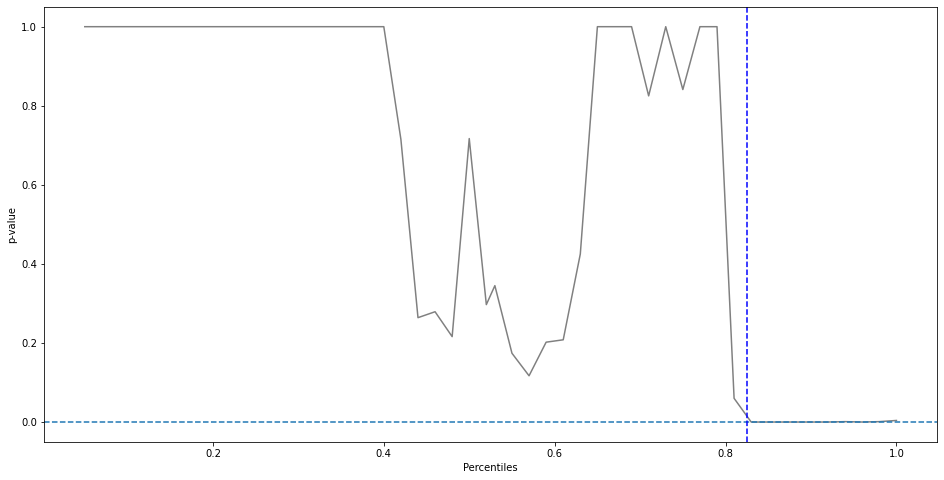

In [83]:
# посмотрим, что получилось
plt.figure(figsize=(16,8))
sns.lineplot(x = np.round(perc_linspace,2), y = p_val_list, color= 'gray')
plt.xlabel("Percentiles")
plt.ylabel("p-value")
plt.axhline(y = (0.05/peek_num), linestyle = '--')
plt.axvline(perc_linspace[p_val_list <= (0.05/peek_num)].min(), linestyle = '--', color = 'blue')

Как видно на графике выше, примерно с 0.75 квантиля мы стабильно видим низкие p-value в проверке гипотез

In [84]:
p_val_list

array([1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 0.715, 0.264, 0.279, 0.216, 0.717, 0.297, 0.345, 0.174,
       0.117, 0.202, 0.208, 0.425, 1.   , 1.   , 1.   , 0.825, 1.   ,
       0.841, 1.   , 1.   , 0.06 , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.001, 0.   , 0.001, 0.004])

Визуализация p-value не самая удобная. Попробуем отрисовать значения доверительного интервала для соответствующих перцентилей.
Также напомню, что доверительные интервалы мы заранее считали со скорректированным на множественную поправку альфа.

Text(0, 0.5, 'Diffs and 95% CI with Bonferoni corr.')

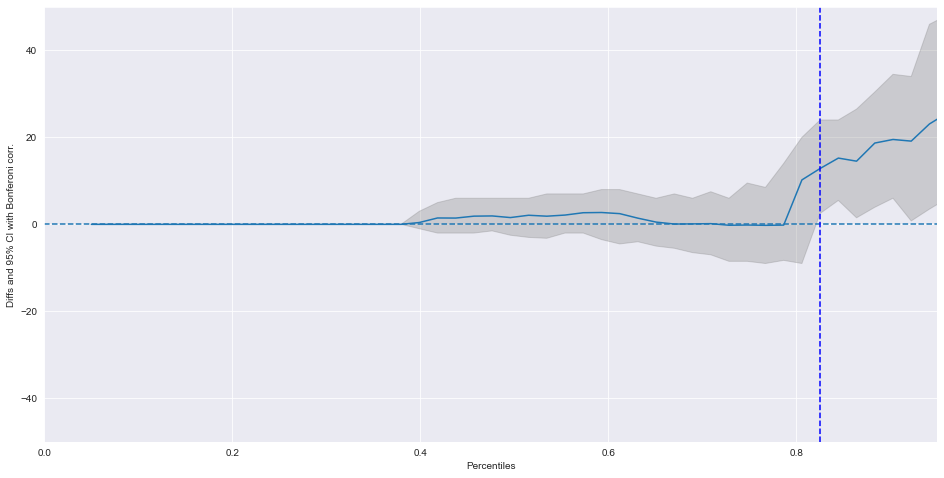

In [85]:
plt.figure(figsize=(16,8))
sns.set_style("darkgrid")
plt.ylim(-50,50)
plt.xlim(0,0.95)
sns.lineplot(x = perc_linspace, y = diffs_list, err_style='band')
plt.axhline(y = 0, linestyle = '--')
plt.axvline(perc_linspace[p_val_list <= (0.05/peek_num)].min(), linestyle = '--', color = 'blue')
plt.fill_between(perc_linspace, lower_ci_list, upper_ci_list, color = 'grey', alpha=0.3)
plt.xlabel("Percentiles")
plt.ylabel("Diffs and 95% CI with Bonferoni corr.")

### Попробуем численно научится находить нужный размер группы, чтобы гарантировано находить нужный эффект в нужном квантиле.

In [129]:
# создадим исходные гиперпарметры для оценки размера выборки и достижения нужной мощности
sample_size_start = 1000
sample_size_step = 100
hist_data = final_ARPU_1
q_effect = 0.79 # с какого квантиля добавляем эффект
effect = 0.1 # относительный размер эффекта накладываемый для квантиля
power_set = 0.8
n_sim = 200
print('Power - Sample size')
# через симуляции найдем, где достигается нужная мощность
power_value_list = []
sample_size_list = []
while True:
    p_value_list = []
    for i in range(n_sim):
        # рандомно выбираем две подвыборки из исторических данных
        group_a = np.random.choice(hist_data, size = sample_size_start, replace = True)
        group_b_with_effect = np.random.choice(hist_data, size = sample_size_start, replace = True)
                
        #добавляем эффект
        q_effect_level = np.quantile(group_b_with_effect, q_effect) # определим нужное значение с которого добавляется эффект
        group_b_with_effect[group_b_with_effect >= q_effect_level] = group_b_with_effect[group_b_with_effect >= q_effect_level]*(1+effect) 
        group_b_with_effect = np.round(group_b_with_effect, 0)
        
        #находим p-value через bootstrap        
        boot_data = bootstrap_ab_test(sample_data_A = group_a,
                  sample_data_B = group_b_with_effect,
                  stat = np.median,
                  resample_num = 100,
                  alpha = 0.05, q = 0.85)
        p_value = boot_data['p_value']
        p_value_list.append(p_value)
    power_value = (np.array(p_value_list) < 0.05).mean()
    power_value_list.append(power_value)
    sample_size_list.append(sample_size_start)
    print(power_value, sample_size_start)
    if power_value > power_set+0.05:
        break
    else:
        sample_size_start += sample_size_step

final_sample_size = sample_size_start
final_power =  power_value

print('Simulation is over!')
print('Final power:', final_power)
print('Final Sample size:', final_sample_size)


Power - Sample size
0.25 1000
0.24 1100
0.19 1200
0.245 1300
0.29 1400
0.29 1500
0.27 1600
0.25 1700
0.305 1800
0.355 1900
0.415 2000
0.37 2100
0.32 2200
0.43 2300
0.385 2400
0.46 2500
0.45 2600
0.42 2700
0.415 2800
0.495 2900
0.555 3000
0.49 3100
0.53 3200
0.48 3300
0.53 3400
0.52 3500
0.52 3600
0.59 3700
0.495 3800
0.625 3900
0.61 4000
0.58 4100
0.585 4200
0.64 4300
0.625 4400
0.62 4500
0.625 4600
0.7 4700
0.63 4800
0.615 4900
0.655 5000
0.72 5100
0.69 5200
0.735 5300
0.71 5400
0.755 5500
0.81 5600
0.765 5700
0.795 5800
0.77 5900
0.77 6000
0.795 6100
0.775 6200
0.795 6300
0.785 6400
0.795 6500
0.795 6600
0.845 6700
0.79 6800
0.84 6900
0.855 7000
Simulation is over!
Final power: 0.855
Final Sample size: 7000


In [87]:
# рассчитаем доверительные интервалы рассчитанной мощности для более информативного использования на графике
lower_ci_list = []
upper_ci_list = []

for power in power_value_list:
    lower_bound, upper_bound = proportion_confint(power*n_sim, n_sim, alpha=0.05)
    lower_ci_list.append(lower_bound)
    upper_ci_list.append(upper_bound)

In [88]:
sample_size_list[np.argmax(np.array(power_value_list) >= 0.8)]

5300

In [95]:
group_b_with_effect.mean() - group_a.mean()

5.148305084745758

Text(5410.0, 0.55, 'Appropr. Sample size = 5600')

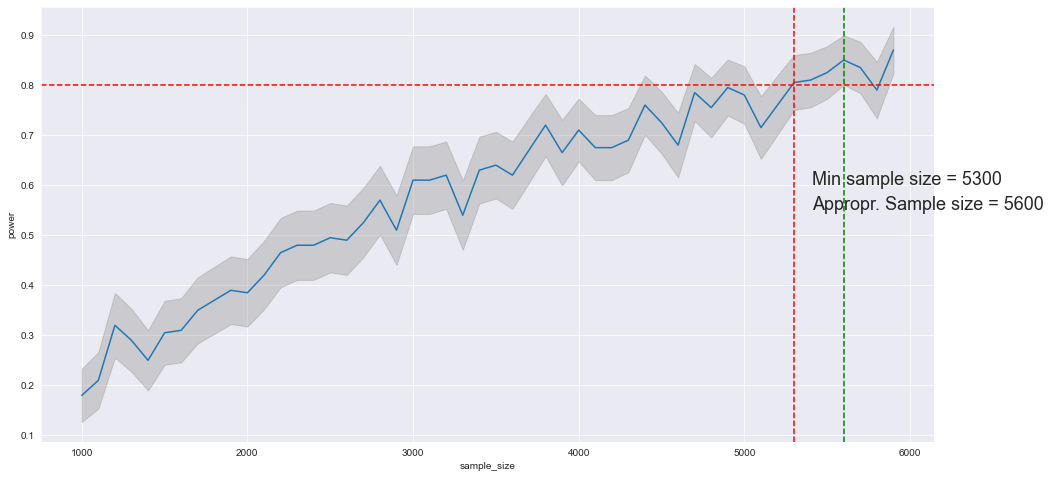

In [114]:
# отрисуем график роста мощности по мере увеличения размера выборки с доверительным интервалом
min_sample_size = sample_size_list[np.argmax(np.array(power_value_list) >= 0.8)] # размер выборки первый раз превысившей 0.8 значение мощности
min_sample_size_lower_ci = sample_size_list[np.argmax(np.array(lower_ci_list) >= 0.8)] # размер выборки, когда 95% ДИ оценки мощности будет стабильно выше

plt.figure(figsize=(16,8))
sns.set_style("darkgrid")
sns.lineplot(x= sample_size_list, y = power_value_list)
plt.axhline(y = 0.8, linestyle = '--', color = 'red')
plt.axvline(x = min_sample_size, linestyle = '--', color = 'red')
plt.axvline(x = min_sample_size_lower_ci, linestyle = '--', color = 'green')

plt.fill_between(sample_size_list, lower_ci_list, upper_ci_list, color = 'grey', alpha=0.3)
plt.xlabel("sample_size")
plt.ylabel("power")
plt.text(x= np.quantile(sample_size_list, 0.9), y= 0.6, fontsize=18, s = 'Min sample size = {}'.format(min_sample_size))
plt.text(x= np.quantile(sample_size_list, 0.9), y= 0.55, fontsize=18, s = 'Appropr. Sample size = {}'.format(min_sample_size_lower_ci))

In [207]:
# сравним какой размер выборки нам подсказала бы формула рассчета размера выборки для ttest

In [134]:
hist_data.mean()
rel_effect = 0.08
abs_lift = group_b_with_effect.mean() - hist_data.mean()
effect_size = abs_lift / hist_data.std()

print('Hist mean:', hist_data.mean())
print('Relative effect', rel_effect)
print('Effect size:', effect_size)
print('Estimated absolute effect =', abs_lift)

sample_size = int(tt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=power, nobs1=None, ratio=1))
print('Sample size = ', sample_size)

Hist mean: 59.6671
Relative effect 0.08
Effect size: 0.054102772952223904
Estimated absolute effect = 5.052042857142858
Sample size =  6509


## Вывод по работе с бутстрапом

НАПИСАТЬ выводы по работе с бутстрапом
Резюме